# tICA dihedrals 3 state

In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

Prepare data

In [2]:
trajectories_labels = ["tica_dihedrals"]



total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# timeseries of distances for contacts presents in pdb2f4k
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)


print("Crystal distances shape", crystal_dist.shape) 
rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]



# ----------------------------
# static distances between residues in the reference structure (pdb2f4k)
# ----------------------------
reference_distances = np.load(
    "../intermediate_outputs/closest_heavy_dist_map.npy"
) * 0.1  # Å to nm
# ---------------------------------------

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
Crystal distances shape (1526041, 53)


Estimate MSM

In [3]:
MSM_LAG_NS = 200
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 30
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj


name = trajectories_labels[0]

data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
dtraj = data["traj"].copy()
centers = data["centers"].copy()
C = tce.fit(dtraj).fetch_model()
submodel = C.submodel_largest(directed=True)
print(f"Submodel for {name} has {submodel.n_states} microstates.")
micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 100)
if np.any(dtrajs_dict[name] == -1):
    print(f"Warning: {name} has unassigned microstates after cleaning.")
msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
msm_dict[name] = msm

MSM lag time in frames: 1000
Submodel for tica_dihedrals has 30 microstates.


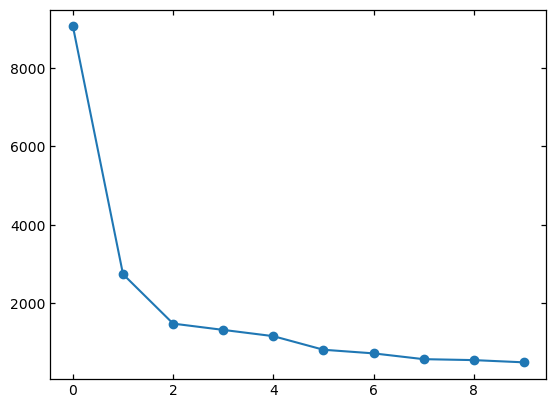

In [4]:
plt.plot(msm.timescales(10), marker='o')

Compute PCCA++ assignments of microstates

In [5]:
n_common = 3

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 3
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

Compute all frame assignments (hard and soft)

In [6]:
pcca_probabilities_timeseries_dict = {}
hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]

    # shape: n_frames x n_macrostates
    p_macro = memberships[dtraj, :]

    # hard macrostate assignment
    hard = np.argmax(p_macro, axis=1)

    pcca_probabilities_timeseries_dict[name] = p_macro
    hard_assignments_timeseries_dict[name] = hard

    print(name)
    print("p_macro shape:", p_macro.shape)
    print("hard shape:", hard.shape)
    print("macrostate counts:", np.bincount(hard))
    print()

tica_dihedrals
p_macro shape: (1526041, 3)
hard shape: (1526041,)
macrostate counts: [  48957  435031 1042053]



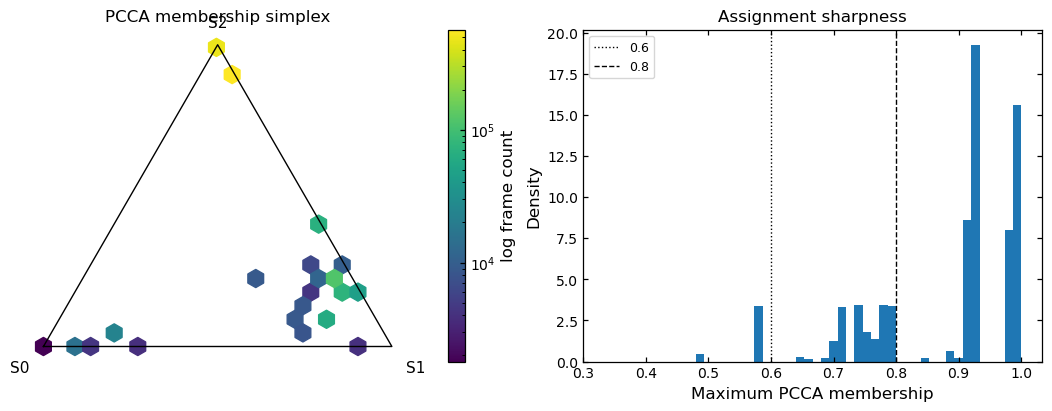

In [7]:
P = pcca_probabilities_timeseries_dict[name]

p0, p1, p2 = P[:, 0], P[:, 1], P[:, 2]
x = p1 + 0.5 * p2
y = (np.sqrt(3) / 2) * p2

max_membership = np.max(P, axis=1)

fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11, 4),
    constrained_layout=True
)

# Panel A: simplex density
hb = axs[0].hexbin(
    x,
    y,
    gridsize=20,
    bins="log",
    #mincnt=1

)

axs[0].plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], color="black", linewidth=1)
axs[0].text(-0.04, -0.04, "S0", ha="right", va="top")
axs[0].text(1.04, -0.04, "S1", ha="left", va="top")
axs[0].text(0.5, np.sqrt(3)/2 + 0.04, "S2", ha="center", va="bottom")
axs[0].set_aspect("equal")
axs[0].axis("off")
axs[0].set_title("PCCA membership simplex")

fig.colorbar(hb, ax=axs[0], label="log frame count")

# Panel B: assignment confidence
axs[1].hist(
    max_membership,
    bins=50,
    range=(1/3, 1),
    density=True
)

axs[1].axvline(0.6, color="black", linestyle=":", linewidth=1, label="0.6")
axs[1].axvline(0.8, color="black", linestyle="--", linewidth=1, label="0.8")

axs[1].set_xlabel("Maximum PCCA membership")
axs[1].set_ylabel("Density")
axs[1].set_title("Assignment sharpness")
axs[1].legend()

plt.show()

S0 and S2 are very sharp, while S1 (the unfolded basin) is more fuzzy. There is no uncertainty regarding assignation of S0 (yes/no).

Define "core" and "transition-like" microstates. Check populations and transition matrix entries

In [8]:
# --------------------------------
# Define masks for each macrostate

core_threshold = 0.7



s0_mask = np.nonzero(pcca_memberships_dict["tica_dihedrals"][:, 0] >= core_threshold)
s1_mask = np.nonzero(pcca_memberships_dict["tica_dihedrals"][:, 1] >= core_threshold)
s2_mask = np.nonzero(pcca_memberships_dict["tica_dihedrals"][:, 2] >= core_threshold)


ambiguous_mask = np.nonzero(
    (pcca_memberships_dict["tica_dihedrals"][:, 0] < core_threshold) &
    (pcca_memberships_dict["tica_dihedrals"][:, 1] < core_threshold) &
    (pcca_memberships_dict["tica_dihedrals"][:, 2] < core_threshold)
) 

print("Macrostate 0 (?) has", len(s0_mask[0]), "microstates.")
print("Macrostate 1 (unfolded) has", len(s1_mask[0]), "microstates.")
print("Macrostate 2 (folded) has", len(s2_mask[0]), "microstates.")
print("Ambiguous microstates have", len(ambiguous_mask[0]), "microstates.")

Macrostate 0 (?) has 6 microstates.
Macrostate 1 (unfolded) has 13 microstates.
Macrostate 2 (folded) has 5 microstates.
Ambiguous microstates have 6 microstates.


Plot macrostate populations

<BarContainer object of 4 artists>

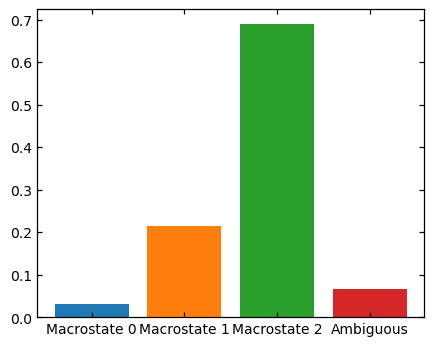

In [9]:
s0_pop = msm_dict["tica_dihedrals"].stationary_distribution[s0_mask]
s1_pop = msm_dict["tica_dihedrals"].stationary_distribution[s1_mask]
s2_pop = msm_dict["tica_dihedrals"].stationary_distribution[s2_mask]
ambiguous_pop = msm_dict["tica_dihedrals"].stationary_distribution[ambiguous_mask]




fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["Macrostate 0", "Macrostate 1", "Macrostate 2", "Ambiguous"],
    [s0_pop.sum(), s1_pop.sum(), s2_pop.sum(), ambiguous_pop.sum()],
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
)

Compute core frames

In [10]:
s0_frames = np.nonzero(np.isin(dtrajs_dict["tica_dihedrals"], s0_mask))[0]
s1_frames = np.nonzero(np.isin(dtrajs_dict["tica_dihedrals"], s1_mask))[0]
s2_frames = np.nonzero(np.isin(dtrajs_dict["tica_dihedrals"], s2_mask))[0]

print("Macrostate 0 (?) has", len(s0_frames), "core frames.")
print("Macrostate 1 (?) has", len(s1_frames), "core frames.")
print("Macrostate 2 (?) has", len(s2_frames), "core frames.")

Macrostate 0 (?) has 48957 core frames.
Macrostate 1 (?) has 333820 core frames.
Macrostate 2 (?) has 1042053 core frames.


---

## Structural Analysis

### Helicity

In [11]:

# --------------------------------
# Helix dict (res idx 1,... 35)
# --------------------------------
helices = {
    "H1": (3, 10),
    "H2": (14, 19),
    "H3": (22, 32),
}

contact_names = np.loadtxt(
    data_folder + "hp35.crystaldists.ndx",
    delimiter=" ",
    dtype=int
)

print("Contact names shape:", contact_names.shape)

# Make sure contact_names is shaped as (n_contacts, 2)
if contact_names.ndim == 1:
    contact_names = contact_names.reshape(-1, 2)

contact_lookup = {i: tuple(contact_names[i]) for i in range(contact_names.shape[0])}

print("First contacts:")
for i in range(min(10, len(contact_lookup))):
    print(i, contact_lookup[i])


# --------------------------------
# Find contacts internal to helices
# --------------------------------

def find_contacts_within_region(contact_names, start, end):
    """
    Return indices of contacts whose two residues both lie in [start, end].

    Assumes contact_names has shape (n_contacts, 2), with residue numbering
    consistent with the helix definitions.
    """
    indices = []

    for k, (res_i, res_j) in enumerate(contact_names):
        if start <= res_i <= end and start <= res_j <= end:
            indices.append(k)

    return np.array(indices, dtype=int)


helix_contact_indices = {}

for helix_name, (start, end) in helices.items():
    idx = find_contacts_within_region(contact_names, start, end)
    helix_contact_indices[helix_name] = idx

    print(f"\n{helix_name}: residues {start}-{end}")
    print(f"Number of internal contacts: {len(idx)}")

    for k in idx:
        print(f"  column {k}: contact {tuple(contact_names[k])}")

Contact names shape: (53, 2)
First contacts:
0 (1, 5)
1 (1, 6)
2 (1, 9)
3 (1, 10)
4 (1, 14)
5 (1, 34)
6 (2, 6)
7 (3, 7)
8 (3, 14)
9 (4, 8)

H1: residues 3-10
Number of internal contacts: 4
  column 7: contact (3, 7)
  column 9: contact (4, 8)
  column 10: contact (5, 9)
  column 11: contact (6, 10)

H2: residues 14-19
Number of internal contacts: 2
  column 32: contact (14, 18)
  column 33: contact (15, 19)

H3: residues 22-32
Number of internal contacts: 7
  column 43: contact (22, 26)
  column 44: contact (23, 27)
  column 45: contact (24, 28)
  column 46: contact (25, 29)
  column 47: contact (26, 30)
  column 48: contact (27, 31)
  column 49: contact (28, 32)


Retrieve distances within helices in the pdb 

In [12]:
reference_distances = np.load(
    "../intermediate_outputs/closest_heavy_dist_map.npy"
) * 0.1  # Å to nm



helix_distances_reference = {}
for helix_name, idx in helix_contact_indices.items():
    start_idxs = [contact_names[k][0] for k in idx]
    print(f"{helix_name} start indices:", start_idxs)
    helix_distances_reference[helix_name] = [reference_distances[i-1, i + 3] for i in start_idxs] # starts from 0
    print(f"{helix_name} reference distances:", helix_distances_reference[helix_name])

H1 start indices: [3, 4, 5, 6]
H1 reference distances: [0.30382633209228516, 0.3010305881500244, 0.2969738721847534, 0.2920261383056641]
H2 start indices: [14, 15]
H2 reference distances: [0.3006548643112183, 0.3289121866226197]
H3 start indices: [22, 23, 24, 25, 26, 27, 28]
H3 reference distances: [0.29214413166046144, 0.2998203992843628, 0.2907871723175049, 0.30020458698272706, 0.3076613187789917, 0.29323320388793944, 0.29776792526245116]


Retrieve distances from samples

In [13]:
helix_distances_s0 = {}
helix_distances_s1 = {}
helix_distances_s2 = {}
for helix_name, idx in helix_contact_indices.items():
    helix_distances_s0[helix_name] = crystal_dist[s0_frames][::100, idx]
    helix_distances_s1[helix_name] = crystal_dist[s1_frames][::100, idx]
    helix_distances_s2[helix_name] = crystal_dist[s2_frames][::100, idx]




def build_contact_distance_dataframe(helix_distances_dict, basin_name):
    rows = []

    for helix_name, distances in helix_distances_dict.items():
        contact_ids = helix_contact_indices[helix_name]

        for local_i, contact_id in enumerate(contact_ids):
            start_res, end_res = contact_lookup[contact_id]
            values = distances[:, local_i]

            for v in values:
                rows.append({
                    "Helix": helix_name,
                    "Contact ID": contact_id,
                    "Start residue": start_res,   
                    "End residue": end_res,
                    "Contact label": f"{start_res}-{end_res}",
                    "Distance": v,
                    "Basin": basin_name
                })

    return pd.DataFrame(rows)


df_s0 = build_contact_distance_dataframe(
    helix_distances_s0,
    "S0"
)

df_s1 = build_contact_distance_dataframe(
    helix_distances_s1,
    "S1"
)

df_s2 = build_contact_distance_dataframe(
    helix_distances_s2,
    "S2"
)

df_contacts = pd.concat([df_s0, df_s1, df_s2], ignore_index=True)

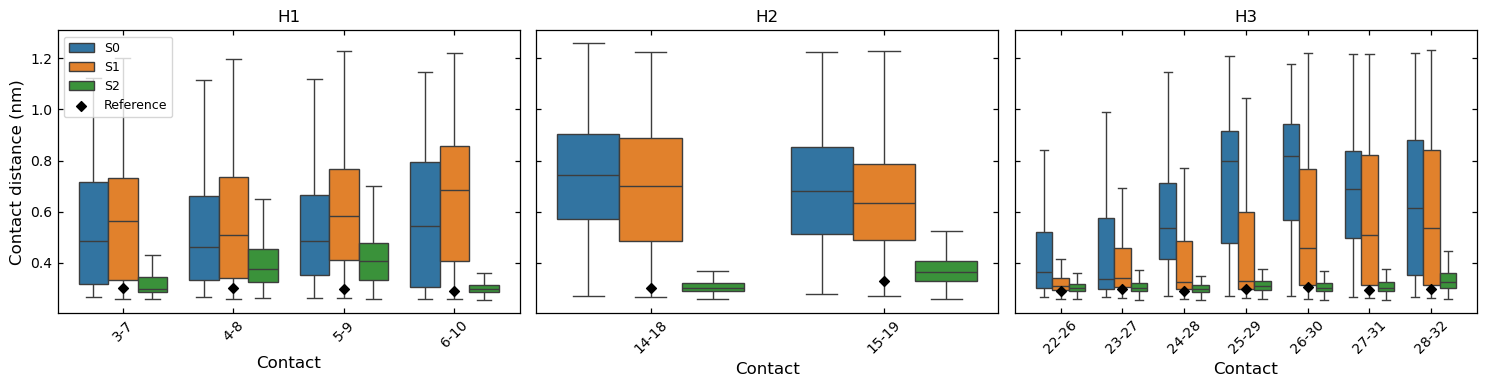

In [14]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharey=True
)

for ax, helix_name in zip(axs, ["H1", "H2", "H3"]):

    sub = df_contacts[df_contacts["Helix"] == helix_name].copy()

    # Keep contact order fixed
    contact_order = sub["Contact label"].drop_duplicates().tolist()

    sns.boxplot(
        data=sub,
        x="Contact label",
        y="Distance",
        hue="Basin",
        order=contact_order,
        showfliers=False,
        ax=ax
    )

    # Reference distances
    ref_x = []
    ref_y = []
    

    for i, contact_id in enumerate(helix_contact_indices[helix_name]):
        start_res, end_res = contact_lookup[contact_id]

        contact_label = f"{start_res}-{end_res}"
        ref_distance = helix_distances_reference[helix_name][i]

        # Skip contacts that are not in the dataframe
        if contact_label not in contact_order:
            continue

        x_pos = contact_order.index(contact_label)

        ref_x.append(x_pos)
        ref_y.append(ref_distance)

    ax.scatter(
        ref_x,
        ref_y,
        color="black",
        marker="D",
        s=25,
        zorder=10,
        label="Reference"
    )


    ax.set_title(helix_name)
    ax.set_xlabel("Contact")
    ax.set_ylabel("Contact distance (nm)")
    ax.tick_params(axis="x", rotation=45)

    # Clean legend
    handles, labels = ax.get_legend_handles_labels()

    if helix_name == "H1":
        # Remove duplicate labels while preserving order
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys(), title="", loc="upper left")
    else:
        ax.get_legend().remove()

plt.tight_layout()



plt.savefig("../output_figures/threestate_tica_helix_differences.pdf", bbox_inches="tight")
plt.savefig("../output_figures/threestate_tica_helix_differences.png", dpi=600, bbox_inches="tight")

### Contact maps

Complete contact maps, compared in the three macrostates

In [15]:
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm

n_res = 35
min_seq_sep = 4


helix_ranges = {
    "H1": (3, 10),
    "H2": (14, 19),
    "H3": (22, 32),
}

In [16]:
def apply_sequence_separation_mask(contact_map, min_seq_sep=4):
    contact_map = contact_map.copy()

    n_res = contact_map.shape[0]

    for i in range(n_res):
        for j in range(n_res):
            if abs(i - j) < min_seq_sep:
                contact_map[i, j] = np.nan

    return contact_map


def decorate_contact_map(ax, n_res=35, helix_ranges=None):
    if helix_ranges is None:
        helix_ranges = {
            "H1": (3, 10),
            "H2": (14, 19),
            "H3": (22, 32),
        }

    # Grid
    ax.set_xticks(np.arange(-0.5, n_res, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_res, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.25, alpha=0.35)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Same-helix blocks
    for hname, (start, end) in helix_ranges.items():
        width = end - start + 1

        rect = Rectangle(
            (start - 1 - 0.5, start - 1 - 0.5),
            width,
            width,
            fill=False,
            linestyle="-",
            linewidth=1.5,
            zorder=4
        )
        ax.add_patch(rect)

        ax.text(
            (start + end) / 2 - 1,
            start - 2.0,
            hname,
            ha="center",
            va="center",
            fontsize=8,
            zorder=5
        )

    # Inter-helix blocks
    helix_items = list(helix_ranges.items())

    for idx_a, (h1, (s1, e1)) in enumerate(helix_items):
        for idx_b, (h2, (s2, e2)) in enumerate(helix_items):
            if idx_b <= idx_a:
                continue

            s1i, e1i = s1 - 1, e1 - 1
            s2i, e2i = s2 - 1, e2 - 1

            w1 = e1i - s1i + 1
            w2 = e2i - s2i + 1

            rect1 = Rectangle(
                (s1i - 0.5, s2i - 0.5),
                w1,
                w2,
                fill=False,
                linestyle="--",
                linewidth=1.1,
                zorder=4
            )

            rect2 = Rectangle(
                (s2i - 0.5, s1i - 0.5),
                w2,
                w1,
                fill=False,
                linestyle="--",
                linewidth=1.1,
                zorder=4
            )

            ax.add_patch(rect1)
            ax.add_patch(rect2)

            ax.text(
                (s1i + e1i) / 2,
                (s2i + e2i) / 2,
                f"{h1}-{h2}",
                ha="center",
                va="center",
                fontsize=7,
                alpha=0.75,
                zorder=5
            )

    # Axis formatting
    ax.set_xlim(-0.5, n_res - 0.5)
    ax.set_ylim(-0.5, n_res - 0.5)
    ax.set_aspect("equal")

    major_ticks = np.arange(0, n_res, 5)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)

    # Show residue labels as 1-based
    ax.set_xticklabels(major_ticks + 1)
    ax.set_yticklabels(major_ticks + 1)

    ax.set_xlabel("Residue index")
    ax.set_ylabel("Residue index")

In [17]:
reference_distances = np.load(
    "../intermediate_outputs/closest_heavy_dist_map.npy"
) * 0.1  # Å to nm

reference_distances = apply_sequence_separation_mask(
    reference_distances,
    min_seq_sep=min_seq_sep
)

In [18]:
def compute_median_distance_map(frames, crystal_dist, contact_names, min_seq_sep=4, n_res=35):
    selected_distances = crystal_dist[frames]

    median_distances = np.nanmedian(selected_distances, axis=0)

    distance_map = np.full((n_res, n_res), np.nan)

    for k, (res_i, res_j) in enumerate(contact_names):
        i = res_i - 1
        j = res_j - 1

        if abs(i - j) < min_seq_sep:
            continue

        distance_map[i, j] = median_distances[k]
        distance_map[j, i] = median_distances[k]

    return distance_map

In [19]:
macro_distance_maps = {
    "S0": compute_median_distance_map(s0_frames, crystal_dist, contact_names, min_seq_sep=min_seq_sep),
    "S1": compute_median_distance_map(s1_frames, crystal_dist, contact_names, min_seq_sep=min_seq_sep),
    "S2": compute_median_distance_map(s2_frames, crystal_dist, contact_names, min_seq_sep=min_seq_sep),
}


reference_distance_map = reference_distances.copy()

delta_distance_maps = {}

for name, distance_map in macro_distance_maps.items():
    delta_distance_maps[f"{name} - reference"] = distance_map - reference_distance_map

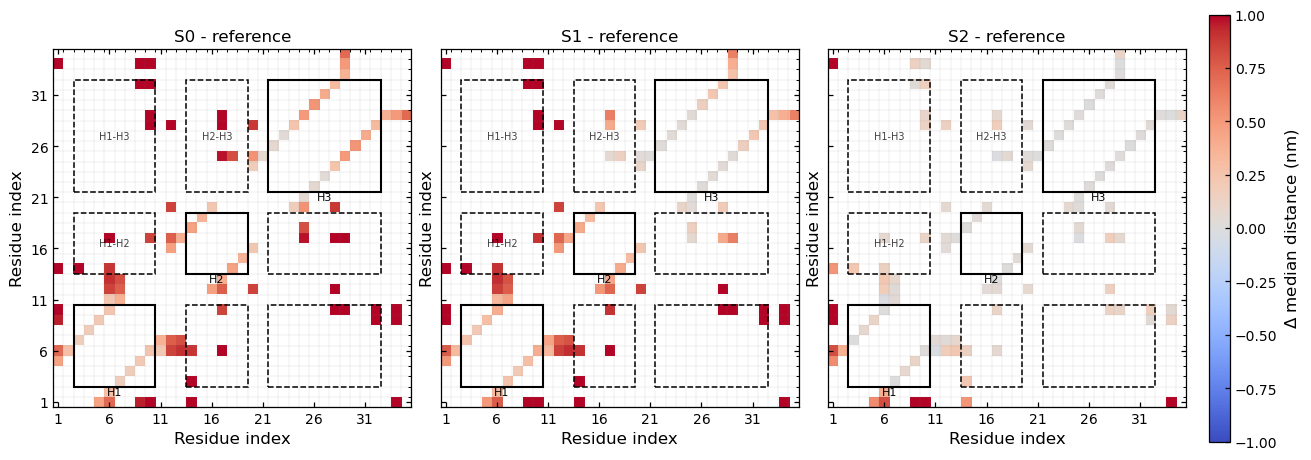

In [20]:
global_vmax = np.nanmax([
    np.nanmax(np.abs(delta_map))
    for delta_map in delta_distance_maps.values()
])

fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(13, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, (title, delta_map) in zip(axs, delta_distance_maps.items()):
    norm = TwoSlopeNorm(vmin=-1, vcenter=0.0, vmax=1)

    im = ax.imshow(
        delta_map,
        origin="lower",
        cmap="coolwarm",
        norm=norm
    )

    ax.set_title(title)
    decorate_contact_map(ax, n_res=n_res, helix_ranges=helix_ranges)

fig.colorbar(
    im,
    ax=axs,
    fraction=0.025,
    pad=0.02,
    label=r"$\Delta$ median distance (nm)"
)

plt.show()

S0 and S1 differ only in details of H2-H3 region

---
#  Fluxes

In [21]:
def compute_equilibrium_traffic(T, pi):
    """
    Compute symmetrized equilibrium transition traffic.

    traffic_ij = pi_i T_ij + pi_j T_ji

    Diagonal entries are set to zero.
    """
    T = np.asarray(T, dtype=float)
    pi = np.asarray(pi, dtype=float)
    pi = pi / pi.sum()

    flux = pi[:, None] * T
    traffic = (flux + flux.T)/2
    np.fill_diagonal(traffic, 0.0)

    return traffic

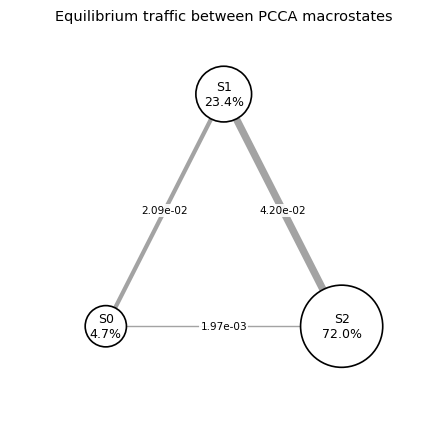

In [22]:
import networkx as nx

# -----------------------------
# Data
# -----------------------------
T = pcca_dict["tica_dihedrals"].coarse_grained_transition_matrix
pi = pcca_dict["tica_dihedrals"].coarse_grained_stationary_probability

traffic = compute_equilibrium_traffic(T, pi)
n_states = len(pi)

# Symmetric traffic between macrostates
traffic_sym = traffic + traffic.T
np.fill_diagonal(traffic_sym, 0)

max_traffic = traffic_sym.max()

# -----------------------------
# Build graph
# -----------------------------
G = nx.Graph()
G.add_nodes_from(range(n_states))

for i in range(n_states):
    for j in range(i + 1, n_states):
        if traffic_sym[i, j] > 0:
            G.add_edge(
                i, j,
                traffic=traffic_sym[i, j],
                weight=traffic_sym[i, j] / max_traffic
            )


# Fixed layout for 3 macrostates: cleaner than spring_layout
# -----------------------------
# Fixed layout with margins
# -----------------------------
pos = {
    0: np.array([0.18, 0.15]),
    1: np.array([0.50, 0.78]),
    2: np.array([0.82, 0.15])
}

# More compact node scaling
node_sizes = 700 + 2800 * pi / pi.max()

edge_widths = [
    0.8 + 4.5 * d["weight"]
    for _, _, d in G.edges(data=True)
]

node_labels = {
    i: f"S{i}\n{100*pi[i]:.1f}%"
    for i in range(n_states)
}

edge_labels = {
    (i, j): f"{d['traffic']:.2e}"
    for i, j, d in G.edges(data=True)
}

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.2))

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    width=edge_widths,
    edge_color="0.55",
    alpha=0.8
)

nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color="white",
    edgecolors="black",
    linewidths=1.2
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=node_labels,
    ax=ax,
    font_size=9
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    ax=ax,
    font_size=7.5,
    rotate=False,
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.9,
        pad=1.0
    )
)

ax.set_title(
    "Equilibrium traffic between PCCA macrostates",
    fontsize=10.5,
    pad=8
)

# Manual margins: important
ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-0.08, 0.95)

ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout(pad=0.6)

plt.savefig(
    "../output_figures/pcca_equilibrium_traffic_network.pdf",
    bbox_inches="tight",
    pad_inches=0.05
)
plt.savefig(
    "../output_figures/dihedrals_pcca_equilibrium_traffic_network.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)



plt.savefig("../output_figures/dihedrals_pcca_equilibrium_traffic_network.pdf", bbox_inches="tight")
plt.savefig("../output_figures/dihedrals_pcca_equilibrium_traffic_network.png", dpi=300, bbox_inches="tight")

S0 represents clearly a relaxation process within the unfolded basin

---
# Struct. visualization with PyMol

In [23]:
# ---- S0 ----

stride = 1600
dihedrals_macro0_frames = np.where(pcca_probabilities_timeseries_dict["tica_dihedrals"][:, 0] > 0.8)[0][::stride]
print("Number of frames assigned to macrostate 0 in tica_dihedrals:", len(dihedrals_macro0_frames))
filepath = "../intermediate_outputs/frame_lists/"
os.makedirs(filepath, exist_ok=True)

filename = os.path.join(filepath, "tica_dihedrals_3state_macro0_frames.npy")
np.save(filename, dihedrals_macro0_frames)

# ---- S1 ----

stride = 400
dihedrals_macro1_frames = np.where(pcca_probabilities_timeseries_dict["tica_dihedrals"][:, 1] > 0.8)[0][::stride]
print("Number of frames assigned to macrostate 1 in tica_dihedrals:", len(dihedrals_macro1_frames))
filename = os.path.join(filepath, "tica_dihedrals_3state_macro1_frames.npy")
np.save(filename, dihedrals_macro1_frames)

# ---- S2 ----

stride = 80000
dihedrals_macro2_frames = np.where(pcca_probabilities_timeseries_dict["tica_dihedrals"][:, 2] > 0.8)[0][::stride]
print("Number of frames assigned to macrostate 2 in tica_dihedrals:", len(dihedrals_macro2_frames))
filename = os.path.join(filepath, "tica_dihedrals_3state_macro2_frames.npy")
np.save(filename, dihedrals_macro2_frames)


Number of frames assigned to macrostate 0 in tica_dihedrals: 14
Number of frames assigned to macrostate 1 in tica_dihedrals: 11
Number of frames assigned to macrostate 2 in tica_dihedrals: 14


# Phi 10 structural caracterization

In [24]:
dihedral_timeseries = np.loadtxt(data_folder + "hp35.dihs", delimiter = " ", dtype = float)
phis_timeseries = dihedral_timeseries[:, 0::2] # degrees
psis_timeseries = dihedral_timeseries[:, 1::2] # degrees

Text(0.5, 0, 'Time (microseconds)')

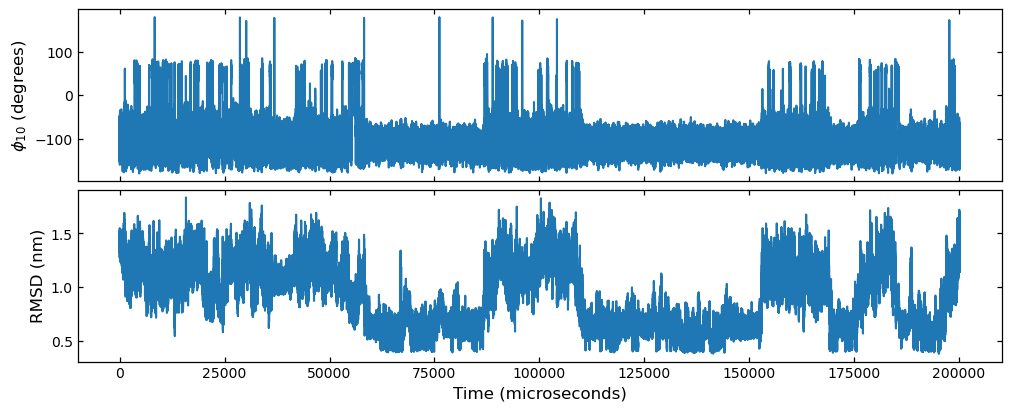

In [25]:
tmin = 0
tmax = 40

idx_min = int(tmin / time_step_micros)
idx_max = int(tmax / time_step_micros)

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 4),
    sharex=True,
    constrained_layout=True
)

phi10_timeseries = phis_timeseries[:, 10 - 2]
axs[0].plot(phi10_timeseries[idx_min:idx_max])
axs[1].plot(rmsd[idx_min:idx_max])

axs[0].set_ylabel(r"$\phi_{10}$ (degrees)")
axs[1].set_ylabel("RMSD (nm)")
axs[1].set_xlabel("Time (microseconds)")

In [26]:
phi10_s0 = {}
phi10_s1 = {}
phi10_s2 = {}

phi10_s0 = phi10_timeseries[s0_frames][::100]
phi10_s1 = phi10_timeseries[s1_frames][::100]
phi10_s2 = phi10_timeseries[s2_frames][::100]

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_82268/2059754146.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


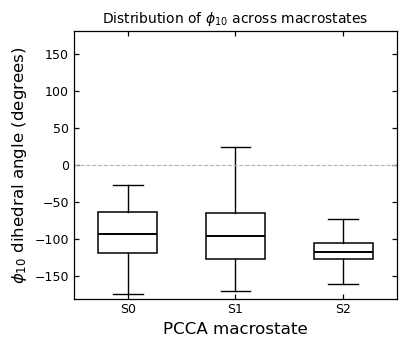

In [27]:
# -----------------------------
# Phi10 values in each macrostate
# -----------------------------
phi10_s0 = phi10_timeseries[s0_frames][::100]
phi10_s1 = phi10_timeseries[s1_frames][::100]
phi10_s2 = phi10_timeseries[s2_frames][::100]

data = [phi10_s0, phi10_s1, phi10_s2]
labels = ["S0", "S1", "S2"]

# Remove possible NaNs
data = [x[~np.isnan(x)] for x in data]

# -----------------------------
# Box plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4.2, 3.6))

bp = ax.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color="black", linewidth=1.4),
    boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.1),
    whiskerprops=dict(color="black", linewidth=1.0),
    capprops=dict(color="black", linewidth=1.0)
)

ax.set_ylabel(r"$\phi_{10}$ dihedral angle (degrees)")
ax.set_xlabel("PCCA macrostate")
ax.set_title(r"Distribution of $\phi_{10}$ across macrostates", fontsize=10)

ax.axhline(0, color="0.7", linewidth=0.8, linestyle="--")
ax.set_ylim(-180, 180)

ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()

os.makedirs("../output_figures", exist_ok=True)
plt.savefig("../output_figures/phi10_boxplot_macrostates.pdf", bbox_inches="tight")
plt.savefig("../output_figures/phi10_boxplot_macrostates.png", dpi=300, bbox_inches="tight")

plt.show()

In [34]:
# -----------------------------
# Define residues to plot
# -----------------------------
# Assuming phis_timeseries[:, 0] corresponds to residue 2.
# Therefore residue 10 -> column index 8.
#residues_to_plot = [9, 10, 11, 12, 13]

#residue_names = ["Val9", "Phe10", "Gly11", "Met12", "Thr13"]
#residue_cols = [r - 2 for r in residues_to_plot]


residues_to_plot = np.arange(19, 25)  # Residues 2 to 33
residue_names = [f"res{r}" for r in residues_to_plot]
residue_cols = [r - 2 for r in residues_to_plot]

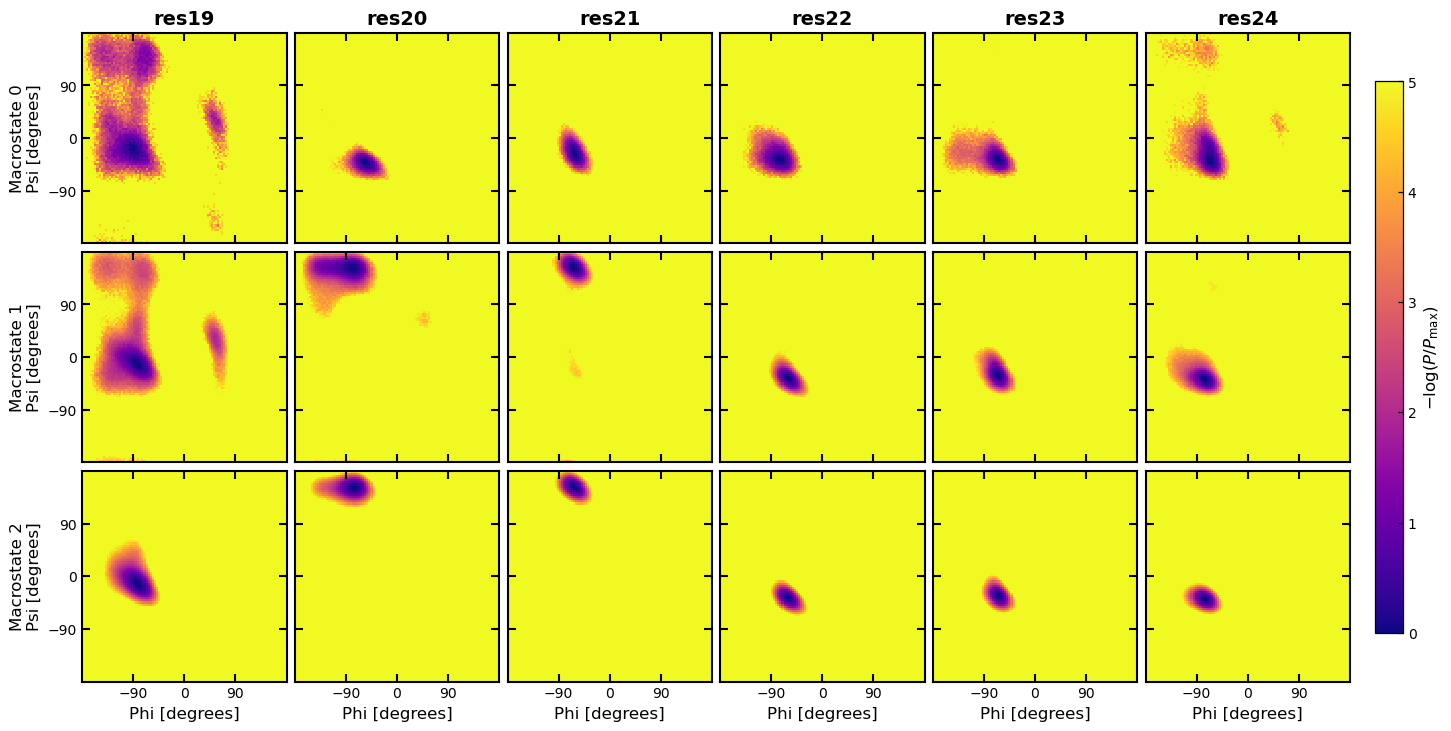

In [35]:

from matplotlib.colors import Normalize

# -----------------------------
# Load dihedrals
# -----------------------------
dihedral_timeseries = np.loadtxt(
    data_folder + "hp35.dihs",
    delimiter=" ",
    dtype=float
)

phis_timeseries = dihedral_timeseries[:, 0::2]   # degrees
psis_timeseries = dihedral_timeseries[:, 1::2]   # degrees





# -----------------------------
# Define macrostate masks
# -----------------------------
# Option A: if you already have frame arrays
macrostate_frames = {
    "Macrostate 0": s0_frames,
    "Macrostate 1": s1_frames,
    "Macrostate 2": s2_frames,
}

# Option B: alternatively, if you have a macrostate assignment time series:
# macrostate_frames = {
#     "Macrostate 0": np.where(macrostate_traj == 0)[0],
#     "Macrostate 1": np.where(macrostate_traj == 1)[0],
#     "Macrostate 2": np.where(macrostate_traj == 2)[0],
# }


# -----------------------------
# Ramachandran free-energy helper
# -----------------------------
def ramachandran_free_energy(phi, psi, bins=100, pseudocount=1e-12):
    """
    Returns bin centers and F = -log(P / Pmax).
    Low F = highly populated.
    """
    H, phi_edges, psi_edges = np.histogram2d(
        phi,
        psi,
        bins=bins,
        range=[[-180, 180], [-180, 180]],
        density=False
    )

    P = H / np.sum(H)
    P = P + pseudocount

    F = -np.log(P / np.max(P))
    F = F.T   # transpose for plotting: y=psi, x=phi

    phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    psi_centers = 0.5 * (psi_edges[:-1] + psi_edges[1:])

    return phi_centers, psi_centers, F


# -----------------------------
# Plot
# -----------------------------
n_rows = len(macrostate_frames)
n_cols = len(residue_cols)

fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.4 * n_cols, 2.4 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

vmax = 5.0
norm = Normalize(vmin=0, vmax=vmax)

last_im = None

for row, (macro_name, frames) in enumerate(macrostate_frames.items()):

    for col, (res_name, res_col) in enumerate(zip(residue_names, residue_cols)):

        ax = axs[row, col]

        phi = phis_timeseries[frames, res_col]
        psi = psis_timeseries[frames, res_col]

        x, y, F = ramachandran_free_energy(phi, psi, bins=100)

        F_plot = np.clip(F, 0, vmax)

        last_im = ax.pcolormesh(
            x,
            y,
            F_plot,
            shading="auto",
            cmap="plasma",
            norm=norm
        )

        # titles only on top row
        if row == 0:
            ax.set_title(res_name, fontsize=14, fontweight="bold")

        # macrostate labels only on left
        if col == 0:
            ax.set_ylabel(f"{macro_name}\nPsi [degrees]", fontsize=12)

        # x labels only on bottom row
        if row == n_rows - 1:
            ax.set_xlabel("Phi [degrees]", fontsize=12)

        ax.set_xlim(-180, 180)
        ax.set_ylim(-180, 180)

        ax.set_xticks([-90, 0, 90])
        ax.set_yticks([-90, 0, 90])

        ax.tick_params(
            direction="in",
            length=6,
            width=1.5,
            top=True,
            right=True
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)


# Shared colorbar
cbar = fig.colorbar(
    last_im,
    ax=axs,
    location="right",
    shrink=0.85,
    pad=0.02
)
cbar.set_label(r"$-\log(P/P_{\max})$", fontsize=12)
cbar.set_ticks([0, 1, 2, 3, 4, 5])

plt.show()

S0 and S1 change for the dihedral distribution of residues 20 and 21. 

These are details of loop 2

Ok but does it have any meaning?

In S0, the second loop is together with helix 2

In S1 and S2, it forms properly as loop.




Hence, reflecting different aspects of the structural dynamics, contacts and dihedrals result in different collective variables and metastable states, eventually leading to MSMs with different time scales and pathways.